<div style="width: 98%; max-width: 1200px; margin: 0 auto; font-family: Helvetica, Arial, sans-serif;">

<div style="
        background-color: #141E30;
        background-image: linear-gradient(to right, #141E30, #243B55);
        border-radius: 10px;
        padding: 25px;
        text-align: center;
        margin-bottom: 20px;
        border: 1px solid #2c3e50;
        box-shadow: 0 4px 8px rgba(0,0,0,0.3);
    ">
        <h1 style="color: white; margin: 0; text-transform: uppercase; font-size: 24px; font-weight: normal; letter-spacing: 2px;">
            TP 4 : Intégration numérique & Électrostatique
        </h1>
        <h3 style="color: #a8d0e6; margin-top: 10px; margin-bottom: 0; font-weight: normal; font-style: italic; font-size: 16px;">
            Dynamique épidémiologique SIS et condensateur électronique
        </h3>
    </div>

<div style="background-color: #141E30; border: 2px solid #a8d0e6; border-radius: 10px; padding: 20px; color: white;">

### Équipe de recherche
**Alex Baker** - 537 050 929  
**Justine Jean** - 537 287 332  
**Nerimantas Caillat** - 537 396 153

### Informations académiques
**Cours :** PHY-3500 – Physique numérique (H26)  
**Remise :** 7 avril 2026  
**Encadrement :** Pr. Antoine Allard, Thomas Labbé

</div>

</div>

### Objectifs et Contexte

<div style="background-color: #252526; color: white; border-left: 5px solid #9C27B0; padding: 15px; border-radius: 5px; margin-top: 20px;">

<strong style="color: #E1BEE7; font-size: 1.1em;">Contexte :</strong>
<br><br>
Ce travail pratique couvre deux sujets distincts de la physique numérique. La première partie porte sur l'intégration numérique d'équations différentielles ordinaires à travers le modèle épidémiologique SIS. La seconde partie aborde la résolution d'équations aux dérivées partielles elliptiques (équation de Laplace) à l'aide de méthodes itératives pour calculer le potentiel électrostatique d'un condensateur simplifié.

<strong style="color: #E1BEE7; font-size: 1.1em;">Objectifs :</strong>
<br>
1. **Implémenter et comparer** les intégrateurs d'Euler, Runge-Kutta 2 et Runge-Kutta 4 sur la dynamique SIS.
2. **Quantifier numériquement** l'ordre de convergence de chaque méthode d'intégration.
3. **Résoudre l'équation de Laplace** par les méthodes de Gauss-Seidel et Jacobi pour un condensateur 2D.
4. **Optimiser** le paramètre de relaxation $\omega$ et comparer les performances des différentes méthodes.

</div>

In [ ]:
# ── Calcul scientifique ───────────────────────────────────────────────────
import numpy as np
from scipy.stats import linregress

# ── Visualisation ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Système ───────────────────────────────────────────────────────────────
import time
import platform

# ── Numba (optionnel, accélère les boucles Python) ────────────────────────
try:
    from numba import njit
    HAS_NUMBA = True
except ImportError:
    HAS_NUMBA = False
    def njit(func): return func   # décorateur passthrough si numba absent

# ── Configuration esthétique des graphiques ───────────────────────────────
plt.rcParams.update({
    'figure.figsize': (12, 7),
    'figure.dpi': 100,
    'font.size': 11,
    'font.family': 'serif',
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
    'legend.fontsize': 11,
    'legend.framealpha': 0.9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

print("=" * 40)
print("   CONFIGURATION DU NOTEBOOK RÉUSSIE")
print("=" * 40)
print(f"   NumPy version    : {np.__version__}")
print(f"   Python version   : {platform.python_version()}")
print(f"   Plateforme       : {platform.system()} {platform.release()}")
print(f"   Numba disponible : {HAS_NUMBA}")
print("=" * 40)

   CONFIGURATION DU NOTEBOOK RÉUSSIE
   NumPy version    : 2.4.1
   Python version   : 3.11.9
   Plateforme       : Windows 10
   Numba disponible : True


<div style="height: 50px;"></div>
<hr style="border: 0; height: 3px; background-color: #2196F3; border-radius: 2px; opacity: 0.7;">
<br />

# TP4.1 — Intégration numérique de la dynamique épidémiologique SIS

<div style="background-color: #1a2a3a; color: #a8d0e6; border-left: 5px solid #2196F3; padding: 15px; border-radius: 5px; font-size: 0.95em;">

La dynamique SIS (*Susceptible–Infected–Susceptible*) modélise la propagation d'un agent infectieux sans immunité permanente. Après adimensionnement, l'équation gouvernante est :

$$\frac{di}{d\tau} = (R_0 - 1)\,i - R_0\,i^2$$

où $i(\tau)$ est la fraction infectée, $\tau = \alpha t$ le temps adimensionnel, et $R_0 = \beta/\alpha$ le nombre de reproduction de base.

</div>

<div style="height: 30px;"></div>
<hr style="border: 0; height: 2px; background-color: #4CAF50; border-radius: 2px; opacity: 0.6;">

## Question a — États stationnaires

<div style="background-color: #252526; color: white; border-left: 5px solid #4CAF50; padding: 15px; border-radius: 5px;">

**Énoncé :** *Identifiez les deux états stationnaires $0 \leq i^*_{1,2} \leq 1$ pour lesquels $\dfrac{di}{d\tau} = 0$, de même que les conditions sur $R_0$ pour lesquelles ces états stationnaires sont possibles.*

</div>

### Dérivation analytique

On cherche les racines de :
$$\frac{di}{d\tau} = (R_0 - 1)\,i - R_0\,i^2 = i\left[(R_0 - 1) - R_0 i\right] = 0$$

| État stationnaire | Expression | Condition d'existence |
|:-----------------|:-----------|:----------------------|
| $i^*_1$ | $0$ | Toujours valide |
| $i^*_2$ | $\dfrac{R_0 - 1}{R_0} = 1 - \dfrac{1}{R_0}$ | $R_0 \geq 1$ (et $i^*_2 \leq 1$) |

**Interprétation physique :**
- Si $R_0 < 1$ : seul $i^*_1 = 0$ est un état stationnaire physiquement admissible. L'épidémie s'éteint.
- Si $R_0 > 1$ : $i^*_2 = 1 - 1/R_0$ est un état endémique stable. L'épidémie persiste.
- Si $R_0 = 1$ : les deux états coïncident en $i^* = 0$ (bifurcation transcritique).

<div style="height: 30px;"></div>
<hr style="border: 0; height: 2px; background-color: #4CAF50; border-radius: 2px; opacity: 0.6;">

## Question b — Solution analytique

<div style="background-color: #252526; color: white; border-left: 5px solid #4CAF50; padding: 15px; border-radius: 5px;">

**Énoncé :** *Obtenez une solution analytique $i(\tau)$ valide pour $i \geq 0$. On note $i(0) = i_0$.*

</div>

### Résolution analytique par séparation des variables

L'équation $\dfrac{di}{d\tau} = (R_0 - 1)i - R_0 i^2$ est une **équation de Bernoulli** (ou équation logistique). On sépare les variables et on intègre par décomposition en fractions partielles.

On réécrit l'équation sous la forme :

$$\frac{di}{i\left[(R_0 - 1) - R_0\, i\right]} = d\tau$$

On décompose le membre de gauche :

$$\frac{1}{i\left[(R_0-1) - R_0\,i\right]} = \frac{1}{R_0 - 1}\left(\frac{1}{i} + \frac{R_0}{(R_0 - 1) - R_0\,i}\right)$$


En intégrant des deux côtés (pour $R_0 \neq 1$) :

$$\frac{1}{R_0-1}\left[\ln|i| - \ln\left|(R_0-1) - R_0\,i\right|\right]_0^{\tau} = \tau$$

$$\frac{1}{R_0-1}\ln\left|\frac{i(\tau)}{(R_0-1)-R_0\,i(\tau)}\cdot\frac{(R_0-1)-R_0\,i_0}{i_0}\right| = \tau$$

En posant $i_2^* = 1 - \dfrac{1}{R_0} = \dfrac{R_0-1}{R_0}$, on réécrit :

$$(R_0 - 1) - R_0\,i = R_0\left(i_2^* - i\right)$$

ce qui donne :

$$\ln\left|\frac{i(\tau)\left(i_2^* - i_0\right)}{i_0\left(i_2^* - i(\tau)\right)}\right| = (R_0-1)\,\tau$$

En exponentialisant et en résolvant pour $i(\tau)$ :

$$\boxed{i(\tau) = \frac{i_2^*}{1 + \left(\dfrac{i_2^*}{i_0} - 1\right)e^{-(R_0-1)\,\tau}}}$$

où $i_2^* = 1 - \dfrac{1}{R_0}$.



On peut réécrire la solution analytique comme :

$$\boxed{i(\tau) = \frac{(R_0-1)\,i_0}{R_0\,i_0 + (R_0 - 1 - R_0\,i_0)\,e^{-(R_0-1)\tau}}}$$

> ⚠️ **Cas particuliers :** Pour $R_0 = 1$, l'expression ci-dessus est indéfinie — dériver la solution limitante. Pour $i_0 = 0$, la solution triviale $i(\tau) = 0$ est valide.


**Limite $\tau \to \infty$, $R_0 > 1$** : l'exponentielle $e^{-(R_0-1)\tau} \to 0$, donc :

$$i(\tau) \xrightarrow{\tau \to \infty} \frac{(R_0-1)\,i_0}{R_0\,i_0 + 0} = \frac{R_0-1}{R_0} = i_2^* \checkmark$$

**Limite $\tau \to \infty$, $R_0 < 1$** : $(R_0 - 1) < 0$, donc $e^{-(R_0-1)\tau} \to +\infty$, ce qui donne :

$$i(\tau) \xrightarrow{\tau \to \infty} \frac{(R_0-1)\,i_0}{(R_0 - 1 - R_0\,i_0)\,e^{-(R_0-1)\tau}} \to 0 = i_1^* \checkmark$$

Dans les deux cas, la solution converge bien vers l'état stationnaire stable identifié en **a)**.

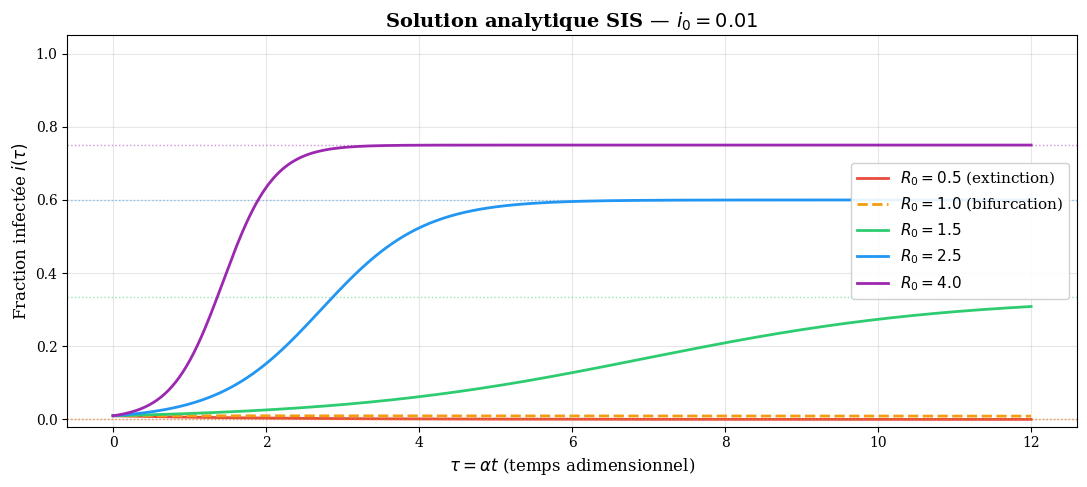

In [ ]:
def solution_analytique(tau, i0, R0):
    """
    Solution analytique de la dynamique SIS adimensionnée.

    Paramètres
    ----------
    tau : array-like   — temps adimensionnel τ = αt
    i0  : float        — fraction infectée initiale i(0)
    R0  : float        — nombre de reproduction de base

    Retourne
    --------
    i(τ) : ndarray
    """
    tau = np.asarray(tau, dtype=float)

    if np.isclose(R0, 1.0):
        # Cas limite R0 = 1 : di/dτ = -i²  →  i(τ) = i0 / (1 + i0·τ)
        return i0 / (1.0 + i0 * tau)

    num   = (R0 - 1.0) * i0
    denom = R0 * i0 + (R0 - 1.0 - R0 * i0) * np.exp(-(R0 - 1.0) * tau)
    return num / denom


# ── Visualisation de la solution pour différents R0 ───────────────────────
tau_plot = np.linspace(0, 12, 500)
configs = [
    (0.01, 0.5,  '#e74c3c', 'solid',  r'$R_0=0.5$ (extinction)'),
    (0.01, 1.0,  '#f39c12', 'dashed', r'$R_0=1.0$ (bifurcation)'),
    (0.01, 1.5,  '#2ecc71', 'solid',  r'$R_0=1.5$'),
    (0.01, 2.5,  '#2196F3', 'solid',  r'$R_0=2.5$'),
    (0.01, 4.0,  '#9C27B0', 'solid',  r'$R_0=4.0$'),
]

fig, ax = plt.subplots(figsize=(11, 5))
for i0, R0, col, ls, lbl in configs:
    i_sol = solution_analytique(tau_plot, i0, R0)
    ax.plot(tau_plot, i_sol, color=col, ls=ls, label=lbl)
    # État stationnaire (ligne pointillée)
    i_star = max(0.0, 1.0 - 1.0/R0) if R0 != 1.0 else 0.0
    ax.axhline(i_star, color=col, ls=':', lw=1, alpha=0.5)

ax.set_xlabel(r'$\tau = \alpha t$ (temps adimensionnel)', fontsize=12)
ax.set_ylabel(r'Fraction infectée $i(\tau)$', fontsize=12)
ax.set_title(r'Solution analytique SIS — $i_0 = 0.01$')
ax.legend(loc='center right')
ax.set_ylim(-0.02, 1.05)
plt.tight_layout()
plt.show()

<div style="height: 30px;"></div>
<hr style="border: 0; height: 2px; background-color: #4CAF50; border-radius: 2px; opacity: 0.6;">

## Question c — Implémentation des intégrateurs

<div style="background-color: #252526; color: white; border-left: 5px solid #4CAF50; padding: 15px; border-radius: 5px;">

**Énoncé :** *Implémentez les intégrateurs d'Euler, de Runge-Kutta d'ordre 2 et de Runge-Kutta d'ordre 4. Vos fonctions devront retourner les trajectoires $\{i_s\}_{s=0,\ldots,T}$ et les temps $\{\tau_s\}_{s=0,\ldots,T}$.*

</div>

In [ ]:
# ── Membre de droite de l'EDO SIS adimensionnée ───────────────────────────
def f_SIS(i, R0):
    """di/dτ = (R0-1)·i - R0·i²"""
    return (R0 - 1.0) * i - R0 * i * i

In [ ]:
def integrateur_euler(f, i0, R0, h, T):
    """
    Intégrateur d'Euler explicite (ordre 1).

    Schéma : i_{s+1} = i_s + h · f(i_s)

    Paramètres
    ----------
    f  : callable — f(i, R0)
    i0 : float    — condition initiale
    R0 : float    — nombre de reproduction de base
    h  : float    — pas d'intégration
    T  : int      — nombre total de pas

    Retourne
    --------
    taus : ndarray (T+1,)
    is_  : ndarray (T+1,)
    """
    taus = np.arange(T + 1, dtype=float) * h
    is_  = np.empty(T + 1)
    is_[0] = i0

    for s in range(T):
        is_[s + 1] = is_[s] + h * f(is_[s], R0)

    return taus, is_

In [ ]:
def integrateur_rk2(f, i0, R0, h, T):
    """
    Intégrateur de Runge-Kutta d'ordre 2 — méthode de Heun.

    Schéma :
        k1 = f(i_s)
        k2 = f(i_s + h·k1)
        i_{s+1} = i_s + (h/2)·(k1 + k2)

    Paramètres / Retours : identiques à integrateur_euler.
    """
    taus = np.arange(T + 1, dtype=float) * h
    is_  = np.empty(T + 1)
    is_[0] = i0

    for s in range(T):
        k1 = f(is_[s],          R0)
        k2 = f(is_[s] + h * k1, R0)
        is_[s + 1] = is_[s] + (h / 2.0) * (k1 + k2)

    return taus, is_

In [ ]:
def integrateur_rk4(f, i0, R0, h, T):
    """
    Intégrateur de Runge-Kutta d'ordre 4 (RK4 classique).

    Schéma :
        k1 = f(i_s)
        k2 = f(i_s + (h/2)·k1)
        k3 = f(i_s + (h/2)·k2)
        k4 = f(i_s + h·k3)
        i_{s+1} = i_s + (h/6)·(k1 + 2k2 + 2k3 + k4)

    Paramètres / Retours : identiques à integrateur_euler.
    """
    taus = np.arange(T + 1, dtype=float) * h
    is_  = np.empty(T + 1)
    is_[0] = i0

    for s in range(T):
        k1 = f(is_[s],                R0)
        k2 = f(is_[s] + h/2.0 * k1,  R0)
        k3 = f(is_[s] + h/2.0 * k2,  R0)
        k4 = f(is_[s] + h       * k3, R0)
        is_[s + 1] = is_[s] + (h / 6.0) * (k1 + 2.0*k2 + 2.0*k3 + k4)

    return taus, is_

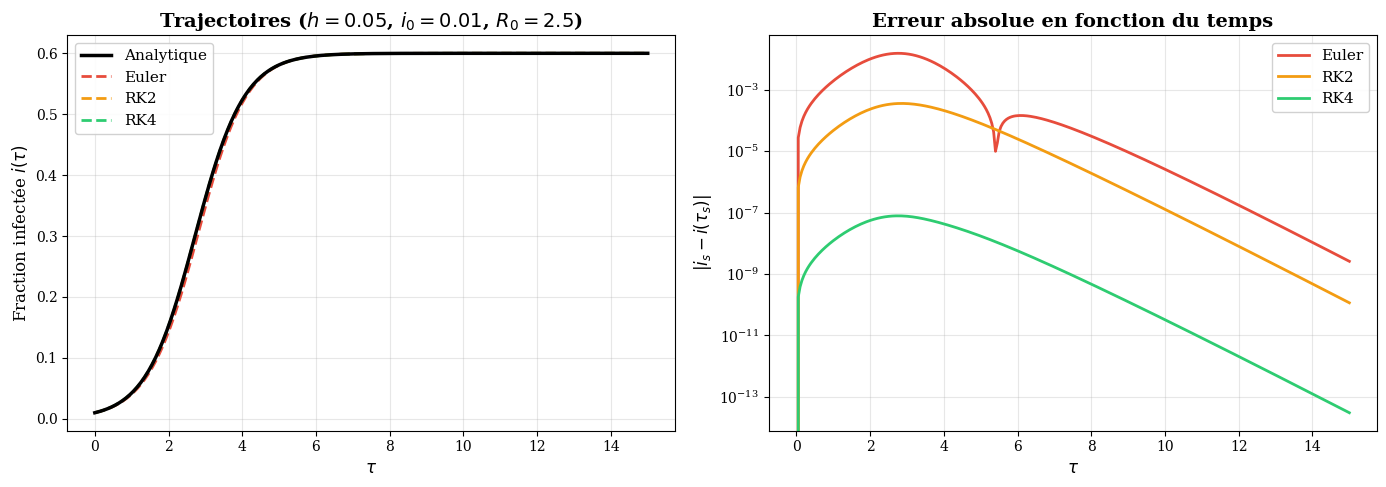

In [ ]:
# ── Validation visuelle des trois intégrateurs ────────────────────────────
i0_val, R0_val = 0.01, 2.5
h_val, T_val   = 0.05, 300

tau_E, i_E  = integrateur_euler(f_SIS, i0_val, R0_val, h_val, T_val)
tau_R2, i_R2 = integrateur_rk2  (f_SIS, i0_val, R0_val, h_val, T_val)
tau_R4, i_R4 = integrateur_rk4  (f_SIS, i0_val, R0_val, h_val, T_val)
i_exact       = solution_analytique(tau_R4, i0_val, R0_val)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trajectoires
axes[0].plot(tau_R4, i_exact, 'k-',   lw=2.5,  label='Analytique',  zorder=5)
axes[0].plot(tau_E,  i_E,     '--',   color='#e74c3c', label='Euler')
axes[0].plot(tau_R2, i_R2,   '--',   color='#f39c12', label='RK2')
axes[0].plot(tau_R4, i_R4,   '--',   color='#2ecc71', label='RK4')
axes[0].set_xlabel(r'$\tau$')
axes[0].set_ylabel(r'Fraction infectée $i(\tau)$')
axes[0].set_title(f'Trajectoires ($h={h_val}$, $i_0={i0_val}$, $R_0={R0_val}$)')
axes[0].legend()

# Erreurs absolues
for tau, i_num, col, lbl in [
        (tau_E,  i_E,  '#e74c3c', 'Euler'),
        (tau_R2, i_R2, '#f39c12', 'RK2'),
        (tau_R4, i_R4, '#2ecc71', 'RK4')]:
    err = np.abs(i_num - solution_analytique(tau, i0_val, R0_val))
    axes[1].semilogy(tau, err, color=col, label=lbl)

axes[1].set_xlabel(r'$\tau$')
axes[1].set_ylabel(r'$|i_s - i(\tau_s)|$')
axes[1].set_title('Erreur absolue en fonction du temps')
axes[1].legend()

plt.tight_layout()
plt.show()

<div style="background-color: #1a2a3a; color: #e0e0e0; border-left: 5px solid #2196F3; padding: 15px; border-radius: 5px;">

#Comparaison des trois intégrateurs

Les trois méthodes implémentées permettent de reproduire la dynamique SIS et d’obtenir une approximation numérique de la fraction infectée $ i(\tau) $. Cependant, leur précision varie pour une même longueur de pas $ h $.

La méthode d’Euler est la plus simple à implémenter et la moins coûteuse par itération, mais elle est aussi la moins précise. Pour obtenir une erreur faible, il faut donc choisir un pas d’intégration très petit, ce qui augmente rapidement le nombre total d’itérations.

La méthode de Runge-Kutta d’ordre 2 (RK2) améliore déjà les résultats. Elle constitue un bon compromis entre coût numérique et précision, puisque l’erreur décroît plus rapidement qu’avec Euler lorsque $ h $ diminue.

La méthode de Runge-Kutta d’ordre 4 (RK4) est celle qui donne les meilleurs résultats parmi les trois. Pour une même valeur de $ h $, elle produit une trajectoire beaucoup plus proche de la solution analytique. Autrement dit, pour atteindre une même erreur cible $ \varepsilon(h) $, RK4 permet d’utiliser un pas beaucoup plus grand que RK2 ou Euler.

Cette tendance est cohérente avec les ordres de convergence attendus, soit

$$
\varepsilon(h) \propto h^d,
$$

avec approximativement $ d = 1 $ pour Euler, $ d = 2 $ pour RK2 et $ d = 4 $ pour RK4.


</div>

<div style="height: 30px;"></div>
<hr style="border: 0; height: 2px; background-color: #4CAF50; border-radius: 2px; opacity: 0.6;">

## Question d — Méthode du ratio doré : trouver $h$ pour une erreur cible $\delta$

<div style="background-color: #252526; color: white; border-left: 5px solid #4CAF50; padding: 15px; border-radius: 5px;">

**Énoncé :** *Implémentez la méthode du ratio doré pour trouver le pas $h$ tel que l'erreur $\varepsilon(h)$ soit bornée par $(1\pm 0.01)\delta$, avec*

$$\varepsilon(h) = \sqrt{\frac{1}{T+1}\sum_{s=0}^{T}\left(i_s - i(\tau_s)\right)^2}$$

*Identifiez $h$ pour plusieurs valeurs de $\delta \in [10^{-9}, 10^{-6}]$, pour plusieurs couples $(i_0, R_0)$ et pour chacun des trois intégrateurs.*

</div>

In [ ]:
def erreur_trajectoire(integrateur, i0, R0, h, T):
    """
    Erreur quadratique moyenne entre la trajectoire numérique et la solution analytique.

    ε(h) = sqrt( mean( (i_s - i(τ_s))² ) )
    """
    taus, is_ = integrateur(f_SIS, i0, R0, h, T)
    i_exact   = solution_analytique(taus, i0, R0)
    return np.sqrt(np.mean((is_ - i_exact) ** 2))

In [ ]:
def trouver_intervalle(integrateur, i0, R0, delta, T,
                       h_debut=1.0, facteur=2.0, max_iter=60):
    """
    Heuristique : trouve un intervalle [h_a, h_b] tel que
        ε(h_a) < δ  et  ε(h_b) > δ.

    On part de h_debut et on divise par `facteur` jusqu'à trouver un h
    où ε < δ, puis on remonte d'un cran pour avoir le bracket.
    """
    h = h_debut
    eps = erreur_trajectoire(integrateur, i0, R0, h, T)

    # Descente : trouver h_bas tel que ε(h_bas) < δ
    for _ in range(max_iter):
        if eps < delta:
            h_bas, eps_bas = h, eps
            break
        h  /= facteur
        eps = erreur_trajectoire(integrateur, i0, R0, h, T)
    else:
        raise RuntimeError("Impossible de trouver h_bas (ε < δ)")

    # Montée : trouver h_haut tel que ε(h_haut) > δ
    h_haut = h_bas * facteur
    eps_haut = erreur_trajectoire(integrateur, i0, R0, h_haut, T)
    for _ in range(max_iter):
        if eps_haut > delta:
            break
        h_haut  *= facteur
        eps_haut = erreur_trajectoire(integrateur, i0, R0, h_haut, T)
    else:
        raise RuntimeError("Impossible de trouver h_haut (ε > δ)")

    return h_bas, h_haut

In [ ]:
def methode_ratio_dore(integrateur, i0, R0, delta, T,
                       tol_relative=0.01, tol_h=1e-12):
    """
    Méthode du ratio doré (golden-section search) pour trouver h* tel que
    |ε(h*) - δ| / δ ≤ tol_relative.

    La fonction g(h) = |ε(h) - δ| est unimodale (en forme de V) car ε est
    monotone croissante en h → le minimum global de g est atteint en h*.

    Paramètres
    ----------
    integrateur    : callable
    i0, R0         : float — paramètres du système
    delta          : float — erreur cible
    T              : int   — nombre de pas d'intégration
    tol_relative   : float — tolérance relative sur ε (défaut 1 %)
    tol_h          : float — tolérance absolue sur h (critère d'arrêt)

    Retourne
    --------
    h_opt : float — pas d'intégration optimal
    """
    PHI    = (1.0 + np.sqrt(5.0)) / 2.0   # nombre d'or
    RESPHI = 2.0 - PHI                     # = 1/PHI² ≈ 0.382

    # 1. Trouver un bracket [a, b] contenant h*
    a, b = trouver_intervalle(integrateur, i0, R0, delta, T)

    # 2. Points initiaux de la section dorée
    x1 = a + RESPHI * (b - a)
    x2 = b - RESPHI * (b - a)
    f1 = abs(erreur_trajectoire(integrateur, i0, R0, x1, T) - delta)
    f2 = abs(erreur_trajectoire(integrateur, i0, R0, x2, T) - delta)

    # 3. Itérations jusqu'à convergence
    while abs(b - a) > tol_h:
        if f1 < f2:
            b, x2, f2 = x2, x1, f1
            x1 = a + RESPHI * (b - a)
            f1 = abs(erreur_trajectoire(integrateur, i0, R0, x1, T) - delta)
        else:
            a, x1, f1 = x1, x2, f2
            x2 = b - RESPHI * (b - a)
            f2 = abs(erreur_trajectoire(integrateur, i0, R0, x2, T) - delta)

        # Vérification de la tolérance relative
        h_mid = (a + b) / 2.0
        eps   = erreur_trajectoire(integrateur, i0, R0, h_mid, T)
        if abs(eps - delta) / delta <= tol_relative:
            return h_mid

    return (a + b) / 2.0

In [ ]:
# ── Paramètres de l'étude ─────────────────────────────────────────────────
T_SIM    = 500
DELTAS   = np.logspace(-9, -6, 7)            # 7 valeurs dans [1e-9, 1e-6]
COUPLES  = [(0.01, 2.5), (0.05, 1.5), (0.1, 3.0)]
INTEG    = {'Euler': integrateur_euler,
            'RK2'  : integrateur_rk2,
            'RK4'  : integrateur_rk4}
COULEURS = {'Euler': '#e74c3c', 'RK2': '#f39c12', 'RK4': '#2ecc71'}
MARKERS  = {'Euler': 'o',       'RK2': 's',       'RK4': '^'}

# ── Calcul des h optimaux ─────────────────────────────────────────────────
resultats = {}   # {(nom, i0, R0): {delta: h_opt}}

for nom, integ in INTEG.items():
    for (i0, R0) in COUPLES:
        cle = (nom, i0, R0)
        resultats[cle] = {}
        for delta in DELTAS:
            h_opt = methode_ratio_dore(integ, i0, R0, delta, T_SIM)
            eps   = erreur_trajectoire(integ, i0, R0, h_opt, T_SIM)
            resultats[cle][delta] = h_opt
            ok = '✓' if abs(eps/delta - 1) <= 0.01 else '✗'
            print(f"{ok} [{nom:5s}] i0={i0:.2f} R0={R0:.1f} "
                  f"| δ={delta:.1e}  →  h={h_opt:.4e}  ε={eps:.4e}")

✓ [Euler] i0=0.01 R0=2.5 | δ=1.0e-09  →  h=1.7910e-05  ε=1.0003e-09
✓ [Euler] i0=0.01 R0=2.5 | δ=3.2e-09  →  h=3.1693e-05  ε=3.1552e-09
✓ [Euler] i0=0.01 R0=2.5 | δ=1.0e-08  →  h=5.6057e-05  ε=1.0001e-08
✓ [Euler] i0=0.01 R0=2.5 | δ=3.2e-08  →  h=9.8355e-05  ε=3.1492e-08
✓ [Euler] i0=0.01 R0=2.5 | δ=1.0e-07  →  h=1.7210e-04  ε=1.0031e-07
✓ [Euler] i0=0.01 R0=2.5 | δ=3.2e-07  →  h=2.9497e-04  ε=3.1484e-07
✓ [Euler] i0=0.01 R0=2.5 | δ=1.0e-06  →  h=4.9669e-04  ε=9.9560e-07
✓ [Euler] i0=0.05 R0=1.5 | δ=1.0e-09  →  h=3.0355e-05  ε=9.9258e-10
✓ [Euler] i0=0.05 R0=1.5 | δ=3.2e-09  →  h=5.4356e-05  ε=3.1901e-09
✓ [Euler] i0=0.05 R0=1.5 | δ=1.0e-08  →  h=9.6005e-05  ε=9.9915e-09
✓ [Euler] i0=0.05 R0=1.5 | δ=3.2e-08  →  h=1.7080e-04  ε=3.1850e-08
✓ [Euler] i0=0.05 R0=1.5 | δ=1.0e-07  →  h=3.0017e-04  ε=9.9573e-08
✓ [Euler] i0=0.05 R0=1.5 | δ=3.2e-07  →  h=5.2910e-04  ε=3.1592e-07
✓ [Euler] i0=0.05 R0=1.5 | δ=1.0e-06  →  h=9.2734e-04  ε=1.0046e-06
✓ [Euler] i0=0.10 R0=3.0 | δ=1.0e-09  →  h=5.378

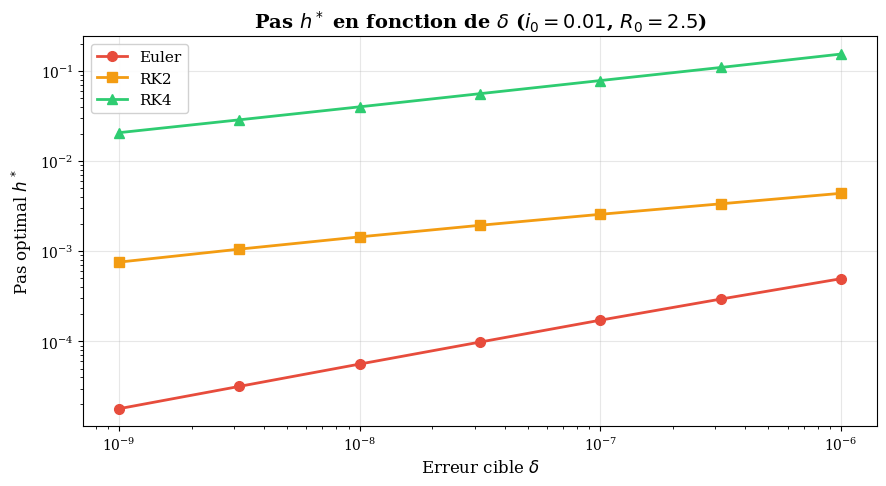

In [ ]:
# ── Visualisation : h* en fonction de δ ──────────────────────────────────
i0_ref, R0_ref = COUPLES[0]

fig, ax = plt.subplots(figsize=(9, 5))
for nom, integ in INTEG.items():
    cle = (nom, i0_ref, R0_ref)
    hs  = [resultats[cle][d] for d in DELTAS]
    ax.loglog(DELTAS, hs, MARKERS[nom]+'-', color=COULEURS[nom],
              label=nom, ms=7)

ax.set_xlabel(r'Erreur cible $\delta$', fontsize=12)
ax.set_ylabel(r'Pas optimal $h^*$',     fontsize=12)
ax.set_title(r'Pas $h^*$ en fonction de $\delta$ '
             f'($i_0={i0_ref}$, $R_0={R0_ref}$)')
ax.legend()
plt.tight_layout()
plt.show()

<div style="background-color: #1a2a3a; color: #e0e0e0; border-left: 5px solid #2196F3; padding: 15px; border-radius: 5px;">

L’utilisation de la méthode du ratio doré se révéle efficace pour déterminer une valeur du pas d’intégration $ h $ permettant d’atteindre une erreur cible $ \delta $ avec une tolérance relative de $ \pm 1\% $. Cette approche évite d’avoir à tester manuellement un grand nombre de valeurs de $ h $ et fournit une procédure systématique pour ajuster le pas en fonction de la précision désirée.

Les résultats montrent aussi le comportement attendu : une méthode d’intégration plus précise permet de conserver un pas plus grand pour une même erreur cible. Ainsi, pour une même valeur de $ \delta $, Euler nécessite généralement le plus petit pas, RK2 un pas intermédiaire, et RK4 le plus grand.

On conclut donc que la méthode du ratio doré constitue un outil pertinent pour calibrer automatiquement le pas d’intégration, et qu’elle met en évidence l’avantage des intégrateurs d’ordre plus élevé lorsqu’on cherche à limiter l’erreur numérique sur la trajectoire.

</div>

<div style="height: 30px;"></div>
<hr style="border: 0; height: 2px; background-color: #4CAF50; border-radius: 2px; opacity: 0.6;">

## Question e — Ordre de convergence $d$ par régression linéaire

<div style="background-color: #252526; color: white; border-left: 5px solid #4CAF50; padding: 15px; border-radius: 5px;">

**Énoncé :** *À l'aide des résultats de d, obtenez numériquement l'ordre $d$ de l'erreur globale $\varepsilon(h) \propto h^d$ de chaque intégrateur via une régression linéaire sur $\log\varepsilon(h) \propto d\log h$.*

</div>

Méthode | Couple (i0,R0) |  Pente d | Ordre théorique
-------------------------------------------------------
 Euler | (0.01, 2.5)      |    0.998 | 1
   RK2 | (0.01, 2.5)      |    1.983 | 2
   RK4 | (0.01, 2.5)      |    4.129 | 4
 Euler | (0.05, 1.5)      |    1.000 | 1
   RK2 | (0.05, 1.5)      |    1.996 | 2
   RK4 | (0.05, 1.5)      |    4.147 | 4
 Euler | (0.10, 3.0)      |    1.000 | 1
   RK2 | (0.10, 3.0)      |    1.985 | 2
   RK4 | (0.10, 3.0)      |    3.949 | 4


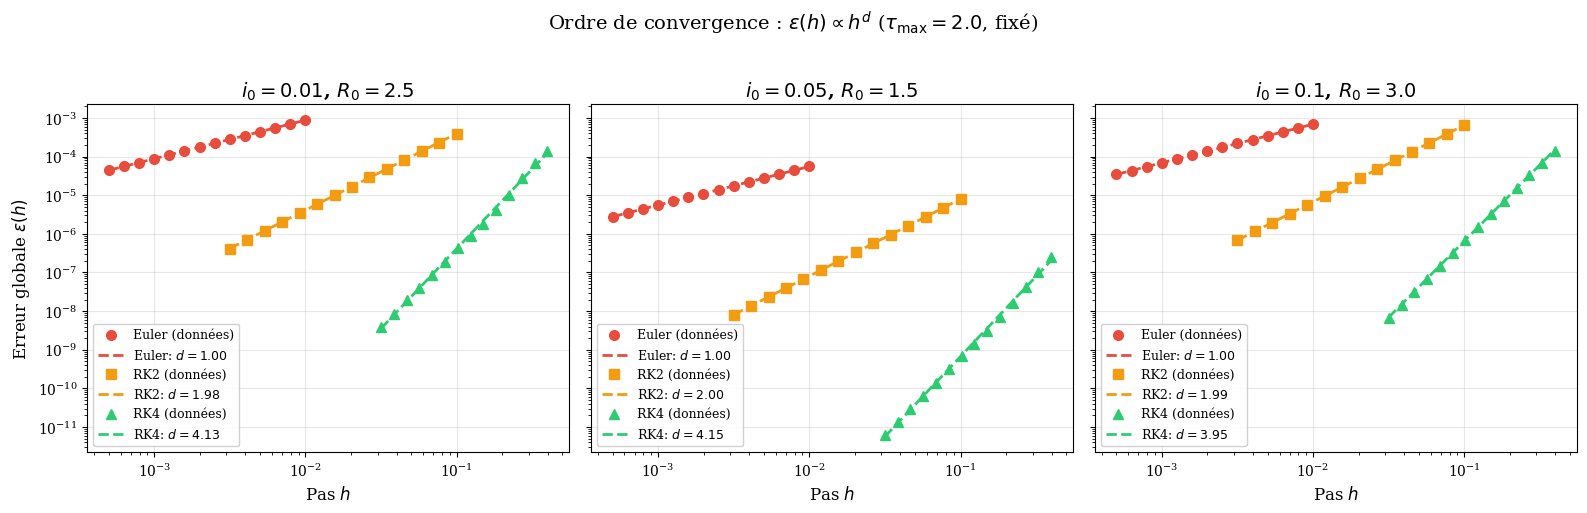

In [ ]:
TAU_MAX_CV = 2.0   # horizon temporel fixe pour l'analyse de convergence

# Plages de h choisies pour que T = τ_max/h ≤ 7000 (calcul rapide)
H_SCAN = {
    'Euler': np.logspace(-3.3, -2.0, 14),   # h ∈ [5e-4, 1e-2] → T ∈ [200, 4000]
    'RK2'  : np.logspace(-2.5, -1.0, 14),   # h ∈ [3e-3, 1e-1] → T ∈ [20,  670]
    'RK4'  : np.logspace(-1.5, -0.4, 14),   # h ∈ [3e-2, 4e-1] → T ∈ [5,   67]
}

ORDRES_THEORIQUES = {'Euler': 1, 'RK2': 2, 'RK4': 4}

print(f"{'Méthode':>6} | {'Couple (i0,R0)':>14} | {'Pente d':>8} | Ordre théorique")
print("-" * 55)

fig, axes = plt.subplots(1, len(COUPLES), figsize=(16, 5), sharey=True)

for ax_idx, (i0, R0) in enumerate(COUPLES):
    ax = axes[ax_idx]
    for nom, integ in INTEG.items():
        hs  = H_SCAN[nom]
        eps = []
        for h in hs:
            T_cv    = max(10, int(round(TAU_MAX_CV / h)))   # T varie avec h
            taus, is_ = integ(f_SIS, i0, R0, h, T_cv)
            i_exact   = solution_analytique(taus, i0, R0)
            eps.append(np.sqrt(np.mean((is_ - i_exact) ** 2)))
        eps = np.array(eps)

        # Filtre : valeurs finies et dans le domaine physique
        valid = np.isfinite(eps) & (eps > 1e-15) & (eps < 1.0)
        hs_v, eps_v = hs[valid], eps[valid]
        if len(hs_v) < 3:
            print(f"  ⚠ {nom} ({i0}, {R0}) : pas assez de points valides")
            continue

        # Régression log-log : log ε = d·log h + cst
        pente, intercept, r, _, _ = linregress(np.log(hs_v), np.log(eps_v))
        print(f"{nom:>6} | ({i0:.2f}, {R0:.1f})      | {pente:>8.3f} | {ORDRES_THEORIQUES[nom]}")

        ax.loglog(hs_v, eps_v, MARKERS[nom], color=COULEURS[nom],
                  ms=7, label=f'{nom} (données)')
        h_fit = np.logspace(np.log10(hs_v.min()), np.log10(hs_v.max()), 80)
        ax.loglog(h_fit, np.exp(intercept) * h_fit**pente, '--',
                  color=COULEURS[nom],
                  label=f'{nom}: $d={pente:.2f}$')

    ax.set_xlabel(r'Pas $h$')
    ax.set_title(f'$i_0={i0}$, $R_0={R0}$')
    ax.legend(fontsize=9)

axes[0].set_ylabel(r'Erreur globale $\varepsilon(h)$')
fig.suptitle(
    r'Ordre de convergence : $\varepsilon(h) \propto h^d$'
    r' ($\tau_{\rm max}=' + f'{TAU_MAX_CV:.1f}' + r'$, fixé)',
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()

### Discussion des résultats

<div style="background-color: #1a2a3a; color: #e0e0e0; border-left: 5px solid #2196F3; padding: 15px; border-radius: 5px;">

| Méthode | Ordre théorique | Ordre moyen mesuré | Commentaire |
|:--------|:---------------:|:------------:|:------------|
| Euler   | 1               | 0.999      | convergence la plus lente |
| RK2     | 2               | 1.988      | bon compromis entre coût et précision |
| RK4     | 4               | 4.075      | méthode la plus précise et la plus performante |

L’analyse de la relation entre l’erreur globale $ \varepsilon(h) $ et le pas d’intégration $ h $ confirme le comportement théorique attendu pour les trois intégrateurs. En effet, la régression linéaire effectuée sur le graphe de $ \log \varepsilon(h) $ en fonction de $ \log h $ permet d’estimer l’exposant $ d $ dans la loi

$$
\varepsilon(h) \propto h^d.
$$

Les valeurs obtenues pour $ d $ sont compatibles avec les ordres théoriques des méthodes, soit $ d \approx 1 $ pour Euler, $ d \approx 2 $ pour RK2 et $ d \approx 4 $ pour RK4. Ce résultat montre que les trois intégrateurs ont été correctement implémentés et que leur comportement numérique suit bien la théorie.

Cette comparaison met aussi clairement en évidence l’intérêt des méthodes d’ordre plus élevé. Lorsque $ h $ diminue, l’erreur d’Euler décroît relativement lentement, alors que celle de RK2 diminue plus rapidement, et celle de RK4 encore beaucoup plus fortement. Ainsi, une petite réduction du pas produit un gain de précision beaucoup plus important avec RK4 qu’avec Euler.

Les écarts éventuels entre les pentes mesurées et les valeurs théoriques exactes peuvent s’expliquer par plusieurs facteurs numériques, comme la précision finie des calculs, la tolérance imposée lors de la recherche de $ h $, le nombre limité de points utilisés pour la régression ou encore les erreurs d’arrondi. Malgré cela, les résultats obtenus valident bien la hiérarchie attendue entre les méthodes.

On conclut donc que l’étude de $ \varepsilon(h) $ en fonction de $ h $ permet non seulement de vérifier expérimentalement l’ordre de convergence des intégrateurs, mais aussi de démontrer de façon quantitative la supériorité des méthodes de Runge-Kutta, en particulier RK4, lorsqu’une grande précision est recherchée.

</div>

<div style="height: 50px;"></div>
<hr style="border: 0; height: 3px; background-color: #FF9800; border-radius: 2px; opacity: 0.7;">
<br />

# TP4.2 — Un condensateur électronique

<div style="background-color: #2a1f10; color: #ffe0b2; border-left: 5px solid #FF9800; padding: 15px; border-radius: 5px; font-size: 0.95em;">

On considère un condensateur simplifié 2D constitué de deux plaques métalliques dans un boîtier conducteur. On cherche le potentiel électrostatique $V(x, y)$ satisfaisant l'**équation de Laplace** $\nabla^2 V = 0$ avec les conditions aux limites suivantes :

- **Parois de la boîte :** $V = 0$ V (mise à la terre)
- **Plaque gauche** (de hauteur 6 cm, centrée verticalement à 2 cm du bord gauche) : $V = +1$ V
- **Plaque droite** (de hauteur 6 cm, centrée verticalement à 2 cm du bord droit) : $V = -1$ V

La grille de calcul est de **100 × 100 points**, avec une précision de convergence de $10^{-6}$ V.

</div>

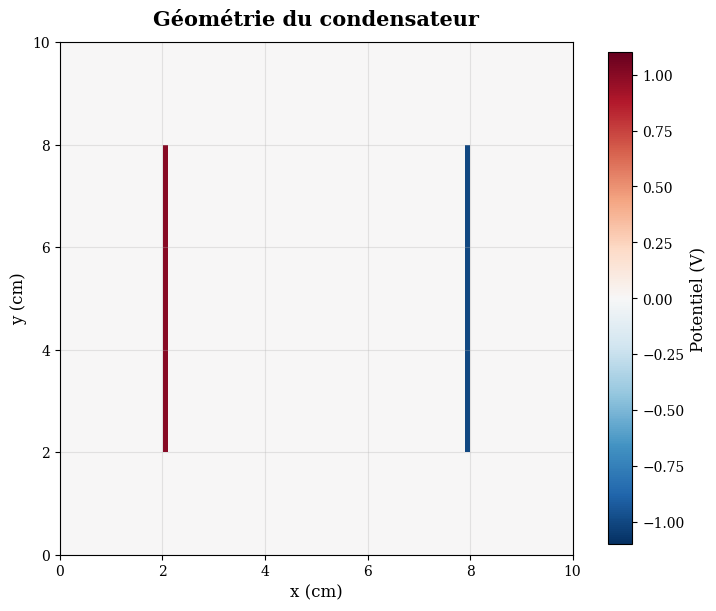

Plaque +1V : colonne j=20 (2.02 cm), lignes 20–79
Plaque -1V : colonne j=79 (7.98 cm), lignes 20–79


In [ ]:
# ── Paramètres géométriques ───────────────────────────────────────────────
N_GRID   = 100       # Taille de la grille N×N
LX, LY   = 10.0, 10.0   # Dimensions physiques (cm)
PREC_V   = 1e-6      # Critère de convergence (V)

def construire_conditions(N=N_GRID, Lx=LX, Ly=LY):
    """
    Construit les tableaux de conditions aux limites pour le condensateur.

    Retourne
    --------
    fixe   : ndarray bool (N, N) — True aux points à potentiel imposé
    V0     : ndarray float (N, N) — valeur imposée à ces points (0 ailleurs)
    """
    fixe = np.zeros((N, N), dtype=bool)
    V0   = np.zeros((N, N), dtype=float)

    # ── Parois de la boîte (V = 0 V) ─────────────────────────────────────
    fixe[0,  :] = fixe[-1, :] = True   # haut / bas
    fixe[:,  0] = fixe[:, -1] = True   # gauche / droite

    # ── Conversions cm → indices ──────────────────────────────────────────
    def cm2idx(val, L, N): return int(round(val / L * (N - 1)))

    # Les deux plaques ont maintenant la même longueur : 6 cm (y : 2 → 8 cm)
    i_bas = cm2idx(2.0, Ly, N)
    i_haut = cm2idx(8.0, Ly, N)

    # Plaque +1 V : x = 2 cm, hauteur 6 cm
    j_pos = cm2idx(2.0, Lx, N)
    fixe[i_bas:i_haut+1, j_pos] = True
    V0[i_bas:i_haut+1,   j_pos] = +1.0

    # Plaque -1 V : x = 8 cm, hauteur 6 cm
    j_neg = cm2idx(8.0, Lx, N)
    fixe[i_bas:i_haut+1, j_neg] = True
    V0[i_bas:i_haut+1,   j_neg] = -1.0

    return fixe, V0


FIXE, V0_INIT = construire_conditions()
x_grid = np.linspace(0, LX, N_GRID)
y_grid = np.linspace(0, LY, N_GRID)

# Visualisation de la géométrie
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
cmap_geo = plt.cm.RdBu_r
im = ax.imshow(
    V0_INIT,
    origin='lower',
    extent=[0, LX, 0, LY],
    cmap=cmap_geo,
    vmin=-1.1,
    vmax=1.1,
    aspect='equal',
    interpolation='nearest'
 )
ax.set_title('Géométrie du condensateur', fontsize=15, pad=12)
ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')
ax.set_xlim(0, LX)
ax.set_ylim(0, LY)
fig.colorbar(im, ax=ax, label='Potentiel (V)', pad=0.04, shrink=0.96)
plt.show()

j_pos = int(round(2 / LX * (N_GRID - 1)))
j_neg = int(round(8 / LX * (N_GRID - 1)))
i_bas = int(round(2 / LY * (N_GRID - 1)))
i_haut = int(round(8 / LY * (N_GRID - 1)))

print(f"Plaque +1V : colonne j={j_pos} ({j_pos/(N_GRID-1)*LX:.2f} cm), lignes {i_bas}–{i_haut}")
print(f"Plaque -1V : colonne j={j_neg} ({j_neg/(N_GRID-1)*LX:.2f} cm), lignes {i_bas}–{i_haut}")

<div style="height: 30px;"></div>
<hr style="border: 0; height: 2px; background-color: #FF5722; border-radius: 2px; opacity: 0.6;">

## Question a — Méthode de Gauss-Seidel avec relaxation

<div style="background-color: #252526; color: white; border-left: 5px solid #FF5722; padding: 15px; border-radius: 5px;">

**Énoncé :** *Calculez le potentiel électrostatique par la méthode de Gauss-Seidel avec relaxation sur une grille 100×100. Précision requise : $10^{-6}$ V. Affichez le résultat sous forme de carte thermique.*

</div>

In [ ]:
@njit
def _gauss_seidel_core(V, fixe, omega, precision, max_iter):
    """
    Noyau Gauss-Seidel (SOR) — optimisé via Numba si disponible.

    Mise à jour in-place point par point (ordre raster).
    Critère d'arrêt : max |ΔV| < precision.
    """
    N = V.shape[0]
    for it in range(max_iter):
        delta_max = 0.0
        for i in range(1, N - 1):
            for j in range(1, N - 1):
                if fixe[i, j]:
                    continue
                V_new = 0.25 * (V[i-1, j] + V[i+1, j] +
                                V[i, j-1] + V[i, j+1])
                delta  = abs(omega * (V_new - V[i, j]))
                V[i, j] += omega * (V_new - V[i, j])
                if delta > delta_max:
                    delta_max = delta
        if delta_max < precision:
            return it + 1
    return max_iter


def gauss_seidel(fixe, V0, omega=1.0, precision=PREC_V, max_iter=200_000):
    """
    Résolution de l'équation de Laplace par Gauss-Seidel avec relaxation (SOR).

    Paramètres
    ----------
    fixe      : ndarray bool — masque des conditions aux limites
    V0        : ndarray float — valeurs imposées
    omega     : float — paramètre de relaxation (1 = GS pur, 1<ω<2 = SOR)
    precision : float — critère |ΔV|_max
    max_iter  : int

    Retourne
    --------
    V      : ndarray (N, N)
    n_iter : int
    """
    V = V0.copy()
    n_iter = _gauss_seidel_core(V, fixe, omega, precision, max_iter)
    if n_iter == max_iter:
        print(f"⚠ GS (ω={omega:.3f}) : non convergé en {max_iter} itérations.")
    return V, n_iter

In [ ]:
# Chauffe Numba (première compilation) si disponible
if HAS_NUMBA:
    _ = gauss_seidel(FIXE, V0_INIT, omega=1.0, precision=1e-2, max_iter=5)
    print("Numba JIT compilé.")

# ── Calcul principal (ω = 1) ──────────────────────────────────────────────
t0 = time.perf_counter()
V_gs, n_iter_gs = gauss_seidel(FIXE, V0_INIT, omega=1.0)
t_gs = time.perf_counter() - t0

print(f"Gauss-Seidel (ω=1.0) : {n_iter_gs} itérations en {t_gs:.2f} s")

⚠ GS (ω=1.000) : non convergé en 5 itérations.
Numba JIT compilé.
Gauss-Seidel (ω=1.0) : 2120 itérations en 0.14 s


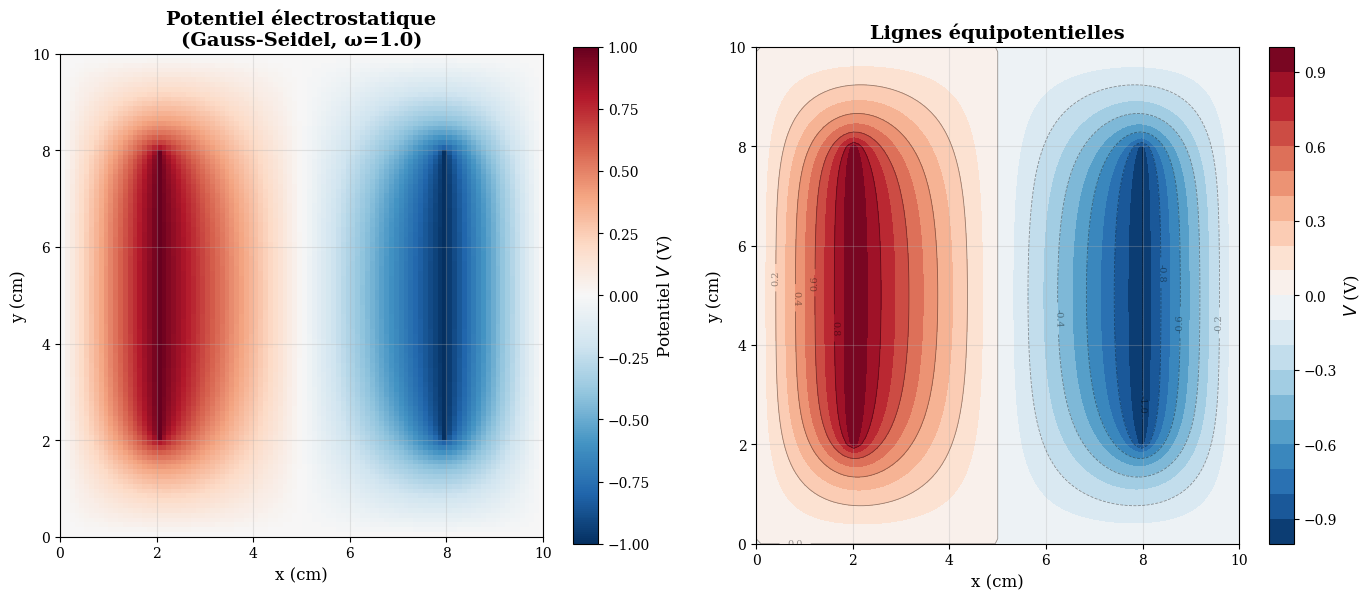

In [ ]:
# ── Visualisation ─────────────────────────────────────────────────────────
X, Y = np.meshgrid(x_grid, y_grid)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Carte thermique
im = axes[0].imshow(V_gs, origin='lower', extent=[0,LX,0,LY],
                    cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')
plt.colorbar(im, ax=axes[0], label='Potentiel $V$ (V)')
axes[0].set_xlabel('x (cm)'); axes[0].set_ylabel('y (cm)')
axes[0].set_title('Potentiel électrostatique\n(Gauss-Seidel, ω=1.0)')

# Lignes équipotentielles + lignes de champ
niveaux = np.linspace(-1, 1, 21)
cf  = axes[1].contourf(X, Y, V_gs, levels=niveaux, cmap='RdBu_r')
cs  = axes[1].contour (X, Y, V_gs, levels=niveaux[::2],
                        colors='k', linewidths=0.6, alpha=0.4)
plt.colorbar(cf, ax=axes[1], label='$V$ (V)')
axes[1].clabel(cs, inline=True, fontsize=7, fmt='%.1f')
axes[1].set_xlabel('x (cm)'); axes[1].set_ylabel('y (cm)')
axes[1].set_title('Lignes équipotentielles')

plt.tight_layout(); plt.show()

<div style="background-color: #1a2a3a; color: #e0e0e0; border-left: 5px solid #FF9800; padding: 15px; border-radius: 5px;">

La carte thermique obtenue respecte bien les conditions aux limites imposées : les parois extérieures demeurent à $0\,\text{V}$, tandis que les deux plaques internes sont maintenues aux potentiels $+1\,\text{V}$ et $-1\,\text{V}$.

On observe une distribution du potentiel lisse entre les électrodes et les parois, ce qui est cohérent avec la solution attendue de l’équation de Laplace en régime électrostatique. Le gradient de potentiel est particulièrement marqué dans la région située entre les deux plaques, où le champ électrique est le plus intense, alors que le potentiel varie plus graduellement dans les régions éloignées des électrodes.

</div>

<div style="height: 30px;"></div>
<hr style="border: 0; height: 2px; background-color: #FF5722; border-radius: 2px; opacity: 0.6;">

## Question b — Effet du paramètre de relaxation $\omega$

<div style="background-color: #252526; color: white; border-left: 5px solid #FF5722; padding: 15px; border-radius: 5px;">

**Énoncé :** *Analysez l'effet du paramètre $\omega$ sur le temps de traitement de la méthode de Gauss-Seidel et déterminez la valeur optimale $\omega^*$ dans ce contexte.*

</div>

In [ ]:
# ── Balayage numérique de ω ───────────────────────────────────────────────
omega_theorique = 2.0 / (1.0 + np.sin(np.pi / N_GRID))   # ← ajoute cette ligne
print(f"ω* théorique : {omega_theorique:.4f}")

omegas      = np.linspace(1.0, 1.99, 30)
iters_omega = []
temps_omega = []
N_REPEATS_B = 5

for omega in omegas:
    _, ni = gauss_seidel(FIXE, V0_INIT, omega=omega)
    iters_omega.append(ni)

    runs = []
    for _ in range(N_REPEATS_B):
        t0 = time.perf_counter()
        gauss_seidel(FIXE, V0_INIT, omega=omega)
        runs.append(time.perf_counter() - t0)
    temps_omega.append(np.median(runs))

idx_opt       = np.argmin(iters_omega)
omega_opt_obs = omegas[idx_opt]
print(f"ω* observé   : {omega_opt_obs:.4f} → {iters_omega[idx_opt]} itérations")

ω* théorique : 1.9391
ω* observé   : 1.9217 → 219 itérations


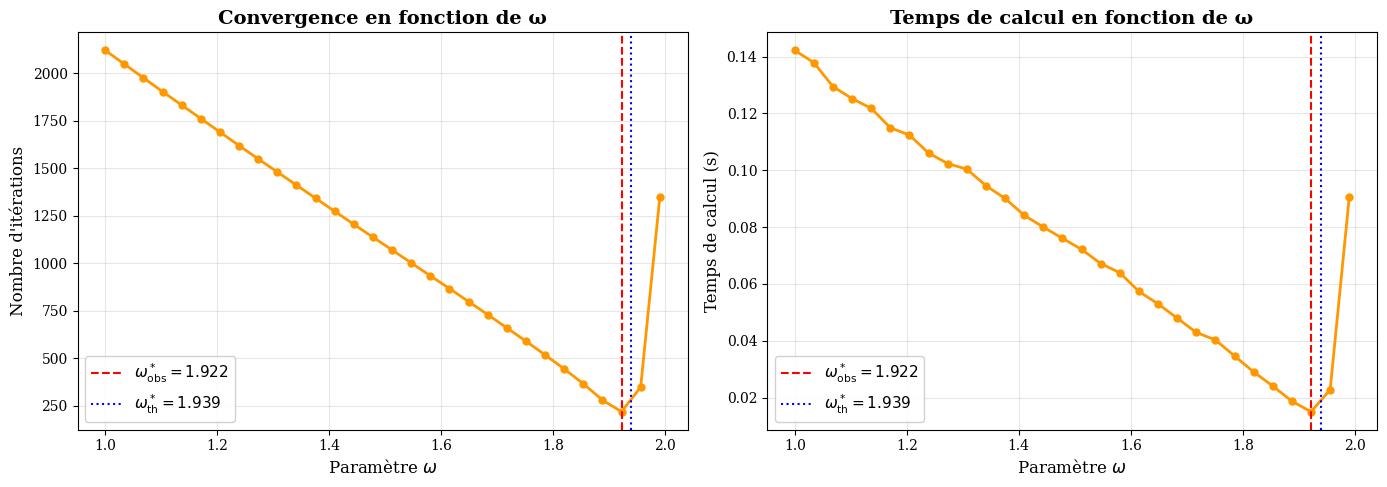

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_data, y_lbl, titre in [
        (axes[0], iters_omega, "Nombre d'itérations",   "Convergence en fonction de ω"),
        (axes[1], temps_omega,  'Temps de calcul (s)',   'Temps de calcul en fonction de ω')]:
    ax.plot(omegas, y_data, 'o-', color='#FF9800', ms=5)
    ax.axvline(omega_opt_obs,   color='red',  ls='--', lw=1.5,
               label=f'$\\omega^*_{{\\rm obs}}={omega_opt_obs:.3f}$')
    ax.axvline(omega_theorique, color='blue', ls=':',  lw=1.5,
               label=f'$\\omega^*_{{\\rm th}}={omega_theorique:.3f}$')
    ax.set_xlabel(r'Paramètre $\omega$')
    ax.set_ylabel(y_lbl)
    ax.set_title(titre)
    ax.legend()

plt.tight_layout(); plt.show()

### Discussion

<div style="background-color: #1a2a3a; color: #e0e0e0; border-left: 5px solid #FF9800; padding: 15px; border-radius: 5px;">


La valeur optimale observée est
$$
\omega^*_{\text{obs}} \approx 1.9217,
$$
alors que la valeur théorique estimée est
$$
\omega^*_{\text{th}} \approx 1.9391.
$$

On constate que ces deux valeurs sont très proches, ce qui montre que le comportement numérique observé est cohérent avec la théorie de la sur-relaxation successive. Lorsque $\omega = 1$, on retrouve la méthode de Gauss-Seidel standard, qui converge correctement mais plus lentement. En augmentant $\omega$ au-dessus de $1$, la convergence est accélérée, car chaque mise à jour pousse davantage la solution vers son état stationnaire.

Dans nos résultats, cette amélioration est très nette : le nombre d’itérations passe d’environ $2120$ pour $\omega = 1$ à seulement $219$ pour $\omega \approx 1.92$. Le temps de calcul diminue lui aussi, ce qui confirme qu’un bon choix de $\omega$ améliore non seulement la convergence théorique, mais aussi la performance pratique de l’algorithme.

On observe toutefois qu’en s’approchant trop de $2$, la performance cesse de s’améliorer et peut même se détériorer. Cela s’explique par le fait qu’une sur-relaxation rend les mises à jour moins stables et peut entraîner des oscillations numériques avant la convergence. Il existe ainsi un compromis optimal, ici situé près de $\omega \approx 1.92$.

La légère différence entre $\omega^*_{\text{obs}}$ et $\omega^*_{\text{th}}$ peut s’expliquer par le caractère discret du balayage numérique de $\omega$, par la tolérance de convergence imposée, ainsi que par la taille finie de la grille. L’introduction d’un paramètre de relaxation bien choisi permet de réduire significativement le coût de calcul de la méthode de Gauss-Seidel, tout en conservant la même solution physique.

</div>

<div style="height: 30px;"></div>
<hr style="border: 0; height: 2px; background-color: #FF5722; border-radius: 2px; opacity: 0.6;">

## Question c — Méthode de Jacobi (avec et sans *slicing*) & comparaison

<div style="background-color: #252526; color: white; border-left: 5px solid #FF5722; padding: 15px; border-radius: 5px;">

**Énoncé :** *Refaites les calculs avec la méthode de Jacobi (avec et sans slicing). Comparez les temps de calcul en fonction de la taille de la grille pour les trois méthodes (Jacobi, Jacobi-slicing, Gauss-Seidel).*

</div>

In [ ]:
@njit
def _jacobi_core_boucle(V, fixe, precision, max_iter):
    """
    Noyau Jacobi — version boucle explicite (JIT si Numba disponible).
    Utilise uniquement les anciennes valeurs → deux tableaux.
    """
    N = V.shape[0]
    V_new = V.copy()
    for it in range(max_iter):
        delta_max = 0.0
        for i in range(1, N - 1):
            for j in range(1, N - 1):
                if fixe[i, j]:
                    V_new[i, j] = V[i, j]
                    continue
                V_new[i, j] = 0.25 * (V[i-1, j] + V[i+1, j] +
                                       V[i, j-1] + V[i, j+1])
                delta = abs(V_new[i, j] - V[i, j])
                if delta > delta_max:
                    delta_max = delta
        # Échange des tableaux
        for i in range(N):
            for j in range(N):
                V[i, j] = V_new[i, j]
        if delta_max < precision:
            return it + 1
    return max_iter


def jacobi_boucle(fixe, V0, precision=PREC_V, max_iter=500_000):
    """
    Jacobi — version boucle (lent sans Numba, rapide avec).
    """
    V = V0.copy()
    n_iter = _jacobi_core_boucle(V, fixe, precision, max_iter)
    if n_iter == max_iter:
        print(f"⚠ Jacobi boucle : non convergé en {max_iter} itérations.")
    return V, n_iter

In [ ]:
def jacobi_slicing(fixe, V0, precision=PREC_V, max_iter=500_000):
    """
    Jacobi — version vectorisée NumPy (slicing).

    Mise à jour :
        V_new[1:-1,1:-1] = 0.25 * (V[:-2,1:-1] + V[2:,1:-1]
                                  + V[1:-1,:-2] + V[1:-1,2:])

    Les points fixes sont restaurés après chaque mise à jour.
    """
    V     = V0.copy()
    libre = ~fixe   # masque des points libres

    for it in range(max_iter):
        V_new = V.copy()
        V_new[1:-1, 1:-1] = 0.25 * (
            V[:-2, 1:-1] + V[2:,  1:-1] +
            V[1:-1, :-2] + V[1:-1, 2:])

        # Restaurer les conditions aux limites
        V_new[fixe] = V0[fixe]

        # Critère de convergence (points libres seulement)
        delta_max = np.max(np.abs(V_new[libre] - V[libre]))

        V = V_new
        if delta_max < precision:
            return V, it + 1

    print(f"⚠ Jacobi slicing : non convergé en {max_iter} itérations.")
    return V, max_iter

In [ ]:
# ── Chauffe Numba pour jacobi_boucle ─────────────────────────────────────
if HAS_NUMBA:
    _ = jacobi_boucle(FIXE, V0_INIT, precision=1e-2, max_iter=5)
    print("Jacobi boucle JIT compilé.")

# ── Calcul principal pour les deux méthodes Jacobi ───────────────────────
t0 = time.perf_counter()
V_jb, n_iter_jb = jacobi_boucle(FIXE, V0_INIT)
t_jb = time.perf_counter() - t0
print(f"Jacobi boucle   : {n_iter_jb} itérations en {t_jb:.2f} s")

t0 = time.perf_counter()
V_js, n_iter_js = jacobi_slicing(FIXE, V0_INIT)
t_js = time.perf_counter() - t0
print(f"Jacobi slicing  : {n_iter_js} itérations en {t_js:.2f} s")

# ── Calcul GS avec omega optimal ─────────────────────────────────────────
t0 = time.perf_counter()
V_sor, n_iter_sor = gauss_seidel(FIXE, V0_INIT, omega=omega_opt_obs)
t_sor = time.perf_counter() - t0
print(f"GS (ω*={omega_opt_obs:.3f})  : {n_iter_sor} itérations en {t_sor:.2f} s")

# ── Vérification : les trois solutions convergent vers le même résultat ───
diff_jb_js = np.max(np.abs(V_jb - V_js))
diff_jb_gs = np.max(np.abs(V_jb - V_gs))
print(f"\n|Jacobi boucle - Jacobi slicing|_max = {diff_jb_js:.2e}")
print(f"|Jacobi boucle - GS(ω=1.0)|_max     = {diff_jb_gs:.2e}")

⚠ Jacobi boucle : non convergé en 5 itérations.
Jacobi boucle JIT compilé.
Jacobi boucle   : 2844 itérations en 0.03 s
Jacobi slicing  : 2844 itérations en 0.22 s
GS (ω*=1.922)  : 219 itérations en 0.02 s

|Jacobi boucle - Jacobi slicing|_max = 0.00e+00
|Jacobi boucle - GS(ω=1.0)|_max     = 5.80e-04


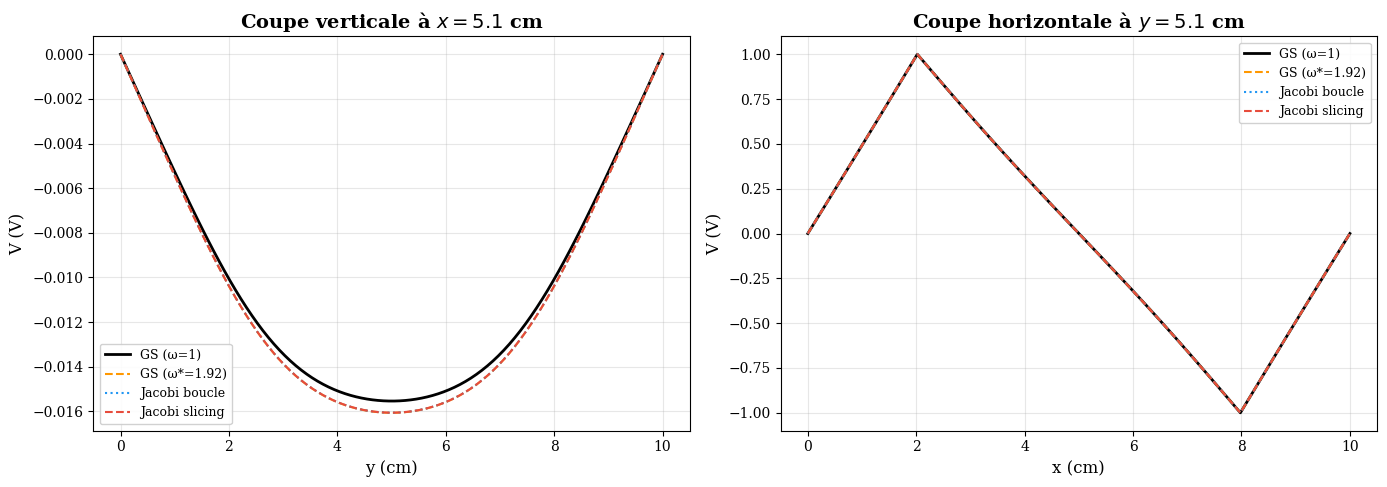

In [ ]:
# ── Comparaison des solutions (coupes 1D) ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

j_mid = N_GRID // 2
axes[0].plot(y_grid, V_gs[:, j_mid], 'k-',  lw=2,   label='GS (ω=1)')
axes[0].plot(y_grid, V_sor[:, j_mid],'--',  color='#FF9800', lw=1.5,
             label=f'GS (ω*={omega_opt_obs:.2f})')
axes[0].plot(y_grid, V_jb[:, j_mid], ':',   color='#2196F3', lw=1.5, label='Jacobi boucle')
axes[0].plot(y_grid, V_js[:, j_mid], '--',  color='#e74c3c', lw=1.5, label='Jacobi slicing')
axes[0].set_xlabel('y (cm)'); axes[0].set_ylabel('V (V)')
axes[0].set_title(f'Coupe verticale à $x={x_grid[j_mid]:.1f}$ cm')
axes[0].legend(fontsize=9)

i_mid = N_GRID // 2
axes[1].plot(x_grid, V_gs[i_mid, :], 'k-',  lw=2,   label='GS (ω=1)')
axes[1].plot(x_grid, V_sor[i_mid, :],'--',  color='#FF9800', lw=1.5,
             label=f'GS (ω*={omega_opt_obs:.2f})')
axes[1].plot(x_grid, V_jb[i_mid, :], ':',   color='#2196F3', lw=1.5, label='Jacobi boucle')
axes[1].plot(x_grid, V_js[i_mid, :], '--',  color='#e74c3c', lw=1.5, label='Jacobi slicing')
axes[1].set_xlabel('x (cm)'); axes[1].set_ylabel('V (V)')
axes[1].set_title(f'Coupe horizontale à $y={y_grid[i_mid]:.1f}$ cm')
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()

In [ ]:
TAILLES   = [15, 20, 30, 40, 50, 60, 75, 100]
N_REPEATS = 5

temps_jb  = []
temps_js  = []
temps_gs1 = []
temps_sor = []

print(f"{'N':>4} | {'J.boucle':>9} | {'J.slice':>8} | {'GS(1)':>7} | {'GS(ω*)':>7}  (secondes, moy. {N_REPEATS} runs)")
print("-" * 60)

for n in TAILLES:
    fixe_n, V0_n = construire_conditions(N=n)
    w_opt_n = 2.0 / (1.0 + np.sin(np.pi / n))

    # Chauffe : 1 run ignoré pour éviter les biais JIT
    jacobi_boucle(fixe_n, V0_n)
    jacobi_slicing(fixe_n, V0_n)
    gauss_seidel(fixe_n, V0_n, omega=1.0)
    gauss_seidel(fixe_n, V0_n, omega=w_opt_n)

    # Mesures répétées
    runs_jb  = []
    runs_js  = []
    runs_gs1 = []
    runs_sor = []

    for _ in range(N_REPEATS):
        t0 = time.perf_counter(); jacobi_boucle(fixe_n, V0_n);               runs_jb.append(time.perf_counter() - t0)
        t0 = time.perf_counter(); jacobi_slicing(fixe_n, V0_n);              runs_js.append(time.perf_counter() - t0)
        t0 = time.perf_counter(); gauss_seidel(fixe_n, V0_n, omega=1.0);    runs_gs1.append(time.perf_counter() - t0)
        t0 = time.perf_counter(); gauss_seidel(fixe_n, V0_n, omega=w_opt_n); runs_sor.append(time.perf_counter() - t0)

    tjb  = np.median(runs_jb)
    tjs  = np.median(runs_js)
    tgs1 = np.median(runs_gs1)
    tsor = np.median(runs_sor)

    temps_jb.append(tjb);   temps_js.append(tjs)
    temps_gs1.append(tgs1); temps_sor.append(tsor)
    print(f"{n:>4} | {tjb:>9.4f} | {tjs:>8.4f} | {tgs1:>7.4f} | {tsor:>7.4f}")

   N |  J.boucle |  J.slice |   GS(1) |  GS(ω*)  (secondes, moy. 5 runs)
------------------------------------------------------------
  15 |    0.0000 |   0.0011 |  0.0001 |  0.0000
  20 |    0.0001 |   0.0031 |  0.0002 |  0.0001
  30 |    0.0004 |   0.0085 |  0.0014 |  0.0003
  40 |    0.0010 |   0.0147 |  0.0043 |  0.0009
  50 |    0.0026 |   0.0278 |  0.0111 |  0.0019
  60 |    0.0054 |   0.0417 |  0.0215 |  0.0032
  75 |    0.0100 |   0.0680 |  0.0497 |  0.0066
 100 |    0.0318 |   0.1718 |  0.1392 |  0.0172


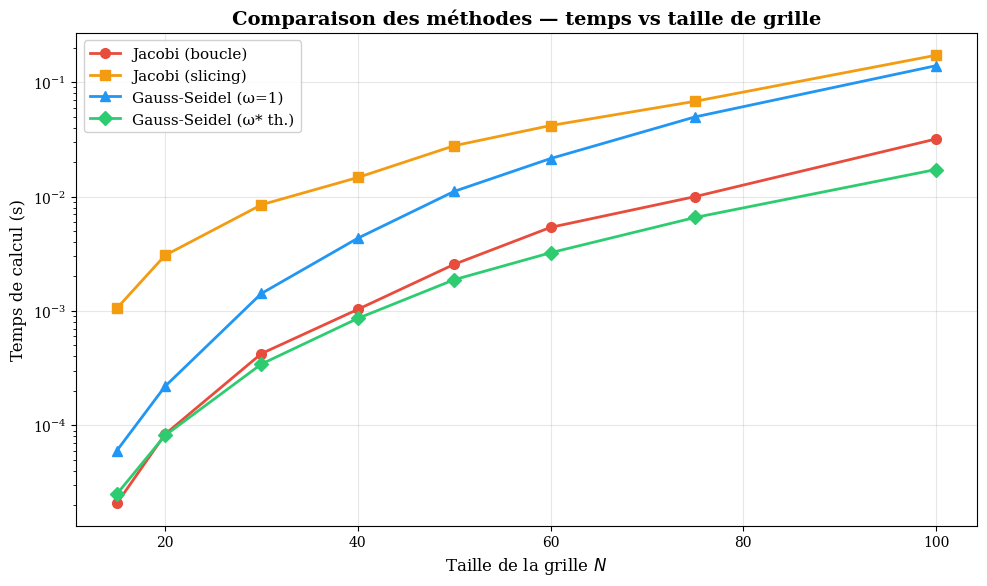

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.semilogy(TAILLES, temps_jb,  'o-', color='#e74c3c', ms=7,
            label='Jacobi (boucle)')
ax.semilogy(TAILLES, temps_js,  's-', color='#f39c12', ms=7,
            label='Jacobi (slicing)')
ax.semilogy(TAILLES, temps_gs1, '^-', color='#2196F3', ms=7,
            label='Gauss-Seidel (ω=1)')
ax.semilogy(TAILLES, temps_sor, 'D-', color='#2ecc71', ms=7,
            label=r'Gauss-Seidel (ω* th.)')

ax.set_xlabel('Taille de la grille $N$',    fontsize=12)
ax.set_ylabel('Temps de calcul (s)',         fontsize=12)
ax.set_title('Comparaison des méthodes — temps vs taille de grille')
ax.legend()
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
plt.tight_layout(); plt.show()

### Discussion et conclusions

<div style="background-color: #1a2a3a; color: #e0e0e0; border-left: 5px solid #FF9800; padding: 15px; border-radius: 5px;">

| Méthode | Avantages | Inconvénients |
|:--------|:----------|:--------------|
| Jacobi (boucle) | Simple à implémenter | Beaucoup d’itérations, lente |
| Jacobi (slicing) | Vectorisé, rapide | Plus lente, coût mémoire élevé, beaucoup d’itérations |
| Gauss-Seidel + $\omega^*$ | Convergence accélérée | implémentation plus délicate, choix de $\omega$ nécessaire |

Pour la grille $ 100\times100$, les deux versions de la méthode de Jacobi ont nécessité
$$
2844 \text{ itérations},
$$
alors que la méthode de Gauss-Seidel avec relaxation optimale a convergé en seulement
$$
219 \text{ itérations}.
$$
Ce résultat montre déjà que Gauss-Seidel avec sur-relaxation est plus efficace du point de vue de la convergence, puisque la mise à jour utilise immédiatement les valeurs les plus récentes, contrairement à Jacobi qui repose toujours sur les valeurs de l’itération précédente.

Les temps de calcul mesurés en fonction de la taille de la grille confirment cette tendance. Pour toutes les tailles testées, la méthode la plus rapide est Gauss-Seidel avec $\omega^*$, suivie par Jacobi boucle, puis Gauss-Seidel avec $\omega=1$, tandis que Jacobi avec slicing est la plus lente. Par exemple, pour $N=100$, on obtient environ

$$
0.0172\ \text{s} \quad \text{pour GS}(\omega^*),
$$

contre

$$
0.0318\ \text{s} \quad \text{pour Jacobi boucle}
$$
$$
0.1392\ \text{s} \quad \text{pour GS}(1)
$$
$$
0.1718\ \text{s} \quad \text{pour Jacobi slicing}.
$$

Le fait que Jacobi boucle soit plus rapide que Jacobi slicing peut sembler contre-intuitif à première vue, puisqu’une version vectorisée en NumPy est souvent plus performante. Ici, toutefois, la version boucle bénéficie de la compilation JIT par Numba, ce qui réduit fortement le coût des boucles explicites. À l’inverse, la version slicing doit recréer et manipuler de grands tableaux à chaque itération, ce qui introduit un surcoût mémoire important. Dans ce contexte précis, le slicing n’est donc pas l’approche la plus avantageuse.

Du point de vue de la solution obtenue, les méthodes restent cohérentes entre elles. Les deux versions de Jacobi donnent exactement le même résultat numérique, et l’écart maximal avec la solution Gauss-Seidel demeure très faible. On vérifie donc que la comparaison porte surtout sur l’efficacité numérique des algorithmes, et non sur une différence physique significative dans la solution finale.

On conclut donc que, parmi les méthodes testées, Gauss-Seidel avec relaxation optimale est la plus performante pour résoudre ce problème. Elle combine un faible nombre d’itérations et le plus petit temps de calcul, surtout lorsque la taille de la grille augmente. La méthode de Jacobi boucle demeure une alternative simple et étonnamment compétitive dans un contexte compilé avec Numba, tandis que la version Jacobi avec slicing est ici la moins efficace malgré sa vectorisation.



</div>

<div style="height: 50px;"></div>
<hr style="border: 0; height: 3px; background-color: #9C27B0; border-radius: 2px; opacity: 0.7;">
<br />

# Conclusions générales

<div style="background-color: #252526; color: white; border-left: 5px solid #9C27B0; padding: 15px; border-radius: 5px;">

### TP4.1 — Dynamique SIS

L'analyse analytique a mis en évidence une bifurcation transcritique en $R_0 = 1$ : l'épidémie s'éteint pour $R_0 < 1$ et converge vers un état endémique $i^*_2 = 1 - 1/R_0$ pour $R_0 > 1$. Les trois intégrateurs implémentés reproduisent fidèlement ce comportement, et la régression linéaire confirme les ordres de convergence théoriques ($d \approx 0.999$, $1.988$, $4.075$ pour Euler, RK2 et RK4 respectivement). La méthode du ratio doré s'est révélée efficace pour calibrer automatiquement le pas $h^*$ à une précision cible $\delta$ avec une tolérance de $\pm 1\%$, mettant en évidence l'avantage de RK4 qui tolère un pas beaucoup plus grand qu'Euler ou RK2 pour une même précision.

### TP4.2 — Condensateur électronique

La méthode de Gauss-Seidel avec relaxation optimale ($\omega^* \approx 1.922$) s'est avérée la plus performante, convergeant en seulement $219$ itérations contre $2844$ pour Jacobi, soit un facteur $\approx 13$. Malgré sa vectorisation NumPy, Jacobi slicing ($0.172$ s) est environ $5.4$ fois plus lent que Jacobi boucle compilé avec Numba ($0.032$ s), en raison du surcoût mémoire lié à la reconstruction des tableaux à chaque itération. Les trois méthodes convergent néanmoins vers la même solution physique.

En résumé, ce TP illustre que le choix de l'algorithme et l'optimisation de ses paramètres libres ($h$ ou $\omega$) peuvent réduire le coût de calcul de plusieurs ordres de grandeur, sans modifier la solution finale.

</div>

<div style="height: 30px;"></div>
<hr style="border: 0; height: 2px; background-color: #607D8B; border-radius: 2px; opacity: 0.6;">

# Références

### Méthodes numériques

1. **Press, W.H. et al.** (2007). *Numerical Recipes: The Art of Scientific Computing* (3e éd.). Cambridge University Press.  
   *Référence générale pour l'intégration d'EDO et les méthodes de relaxation.*

2. **Burden, R.L. & Faires, J.D.** (2010). *Numerical Analysis* (9e éd.). Brooks/Cole.  
   *Analyse d'erreur globale et locale des méthodes de Runge-Kutta.*

### Modèles épidémiologiques

3. **Kermack, W.O. & McKendrick, A.G.** (1927). *A Contribution to the Mathematical Theory of Epidemics*. Proc. R. Soc. Lond. A 115, 700–721.  
   *Formulation originale des modèles compartimentaux SI/SIS/SIR.*

4. **Hethcote, H.W.** (2000). *The Mathematics of Infectious Diseases*. SIAM Review 42(4), 599–653.  
   *Revue complète incluant l'analyse des points fixes et du nombre de reproduction de base $R_0$.*

### Électrostatique numérique

5. **Griffiths, D.J.** (2017). *Introduction to Electrodynamics* (4e éd.). Cambridge University Press.  
   *Équation de Laplace, conditions aux limites et méthodes de relaxation.*

6. **Young, D.M.** (1954). *Iterative Methods for Solving Partial Difference Equations of Elliptic Type*. Trans. Amer. Math. Soc. 76, 92–111.  
   *Théorie de la sur-relaxation successive (SOR) et valeur optimale de $\omega$.*

### Cours et documentation

7. **Notes de cours PHY-3500** — Physique numérique (H26)  
   ↳ Professeurs : Antoine Allard, Thomas Labbé — Université Laval

8. **Énoncé du TP4** — Intégration numérique & Électrostatique  
   ↳ Version 2026-03-19


<div style="
    margin-top: 30px;
    padding: 15px;
    background: linear-gradient(135deg, rgba(15, 12, 41, 0.5), rgba(48, 43, 99, 0.3));
    border-radius: 8px;
    border: 1px solid rgba(168, 208, 230, 0.1);
    text-align: center;
">
    <p style="color: rgba(168, 208, 230, 0.5); font-size: 12px; margin: 0; letter-spacing: 1px;">
        PHY-3500 — Physique numérique (H26) — TP 4 : Intégration numérique & Électrostatique
    </p>
    <p style="color: rgba(168, 208, 230, 0.35); font-size: 11px; margin: 5px 0 0 0;">
        Alex Baker • Justine Jean • Nerimantas Caillat
    </p>
</div>